Chuẩn bị dữ liệu cho bài toán phân loại:

In [ ]:
from torchvision import datasets
import torch
import matplotlib.pyplot as plt
import numpy as np

data_folder = '~/data/FMNIST'
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)

Tiếp theo, chúng ta phải lưu trữ những hình ảnh có sẵn trong fmnist.data với biến tr_images và
các nhãn (targets) có sẵn trong fmnist.targets với tên biến tr_targets:



In [ ]:
tr_images = fmnist.data
tr_targets = fmnist.targets

Kiểm tra các tensor mà chúng ta đang xử lý:


In [ ]:
unique_values = tr_targets.unique()
print(f'tr_images & tr_targets:\n\tX - {tr_images.shape}\n\tY - {tr_targets.shape}\n\tY - Unique Values : {unique_values}')
print(f'TASK:\n\t{len(unique_values)} class Classification')
print(f'UNIQUE CLASSES:\n\t{fmnist.classes}')

tr_images & tr_targets:
	X - torch.Size([60000, 28, 28])
	Y - torch.Size([60000])
	Y - Unique Values : tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
TASK:
	10 class Classification
UNIQUE CLASSES:
	['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


Import các gói có liên quan để vẽ đồ thị các hình ảnh và để bạn cũng có thể làm việc trên các
mảng:


In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np


Tạo một biểu đồ trong đó chúng ta có thể hiển thị một lưới 10 x 10, trong đó mỗi hàng của lưới
tương ứng với một lớp và mỗi cột trình bày một hình ảnh mẫu thuộc về lớp của hàng. Lặp lại các
số lớp duy nhất (label_class) và tìm nạp chỉ mục của các hàng (label_x_rows) tương ứng với số
lớp đã cho:

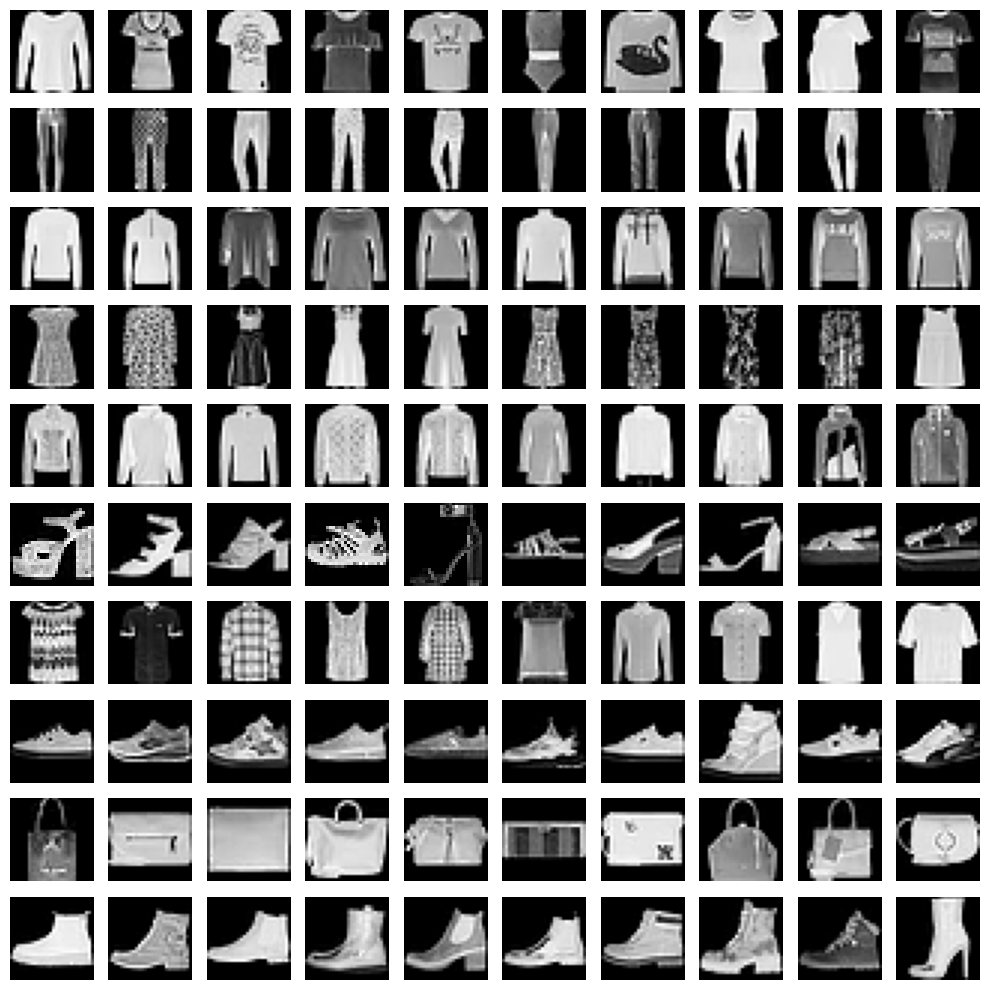

In [ ]:
R, C = len(tr_targets.unique()), 10
fig, ax = plt.subplots(R, C, figsize=(10,10))

for label_class, plot_row in enumerate(ax):
    label_x_rows = np.where(tr_targets == label_class)[0]
    for plot_cell in plot_row:
        plot_cell.grid(False)
        plot_cell.axis('off')
        ix = np.random.choice(label_x_rows)
        x, y = tr_images[ix], tr_targets[ix]
        plot_cell.imshow(x, cmap='gray')

plt.tight_layout()
plt.show()

3. Huấn luyện mạng nơ-ron

1. Import các gói có liên quan và bộ dữ liệu FMNIST:

In [ ]:
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
device = "cuda" if torch.cuda.is_available() else "cpu"
from torchvision import datasets
data_folder = '~/data/FMNIST' # This can be any directory you want to
# download FMNIST to
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)

2. Xây dựng một lớp tìm nạp tập dữ liệu. Chúng ta cần ba hàm __init__, __getitem__ và
__len__:

In [ ]:
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float()
        x = x.view(-1, 28*28)
        self.x, self.y = x, y

    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        return x.to(device), y.to(device)

    def __len__(self):
        return len(self.x)

3. Tạo một hàm tạo DataLoader – trn_dl từ tập dữ liệu – được gọi là FMNISTDataset. Điều này
sẽ lấy mẫu 32 ảnh ngẫu nhiên cho kích thước bó:

In [ ]:
def get_data():
  train = FMNISTDataset(tr_images, tr_targets)
  trn_dl = DataLoader(train, batch_size=32, shuffle=True)
  return trn_dl


4. Xác định một mô hình, cũng như hàm sai số và trình tối ưu hóa:


In [ ]:
from torch.optim import SGD
def get_model():
  model = nn.Sequential(
  nn.Linear(28 * 28, 1000),
  nn.ReLU(),
  nn.Linear(1000, 10)
  ).to(device)
  loss_fn = nn.CrossEntropyLoss()
  optimizer = SGD(model.parameters(), lr=1e-2)
  return model, loss_fn, optimizer
tr_images = fmnist.data
tr_targets = fmnist.targets

5. Xác định hàm sẽ huấn luyện tập dữ liệu trên một loạt hình ảnh:



In [ ]:
def train_batch(x, y, model, opt, loss_fn):
  model.train() # <- let's hold on to this until we reach dropout section
  # call your model like any python function on your batch of inputs
  prediction = model(x)
  # compute loss
  batch_loss = loss_fn(prediction, y)
  # based on the forward pass in `model(x)` compute all the gradients of
  # 'model.parameters()'
  batch_loss.backward()
  # apply new-weights = f(old-weights, old-weight-gradients) where
  # "f" is the optimizer
  optimizer.step()
  # Flush gradients memory for next batch of calculations
  optimizer.zero_grad()
  return batch_loss.item()

6. Xây dựng hàm tính toán độ chính xác của tập dữ liệu nhất định:


In [ ]:
# since there's no need for updating weights,
# we might as well not compute the gradients.
# Using this '@' decorator on top of functions
# will disable gradient computation in the entire function
@torch.no_grad()
def accuracy(x, y, model):
  model.eval() # <- let's wait till we get to dropout section
  # get the prediction matrix for a tensor of `x` images
  prediction = model(x)
  # compute if the location of maximum in each row coincides
  # with ground truth
  max_values, argmaxes = prediction.max(-1)
  is_correct = argmaxes == y
  return is_correct.cpu().numpy().tolist()


7. Huấn luyện mạng nơ-ron bằng cách sử dụng các đoạn code sau:

0
1
2
3
4


/tmp/ipykernel_263/2106312271.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in


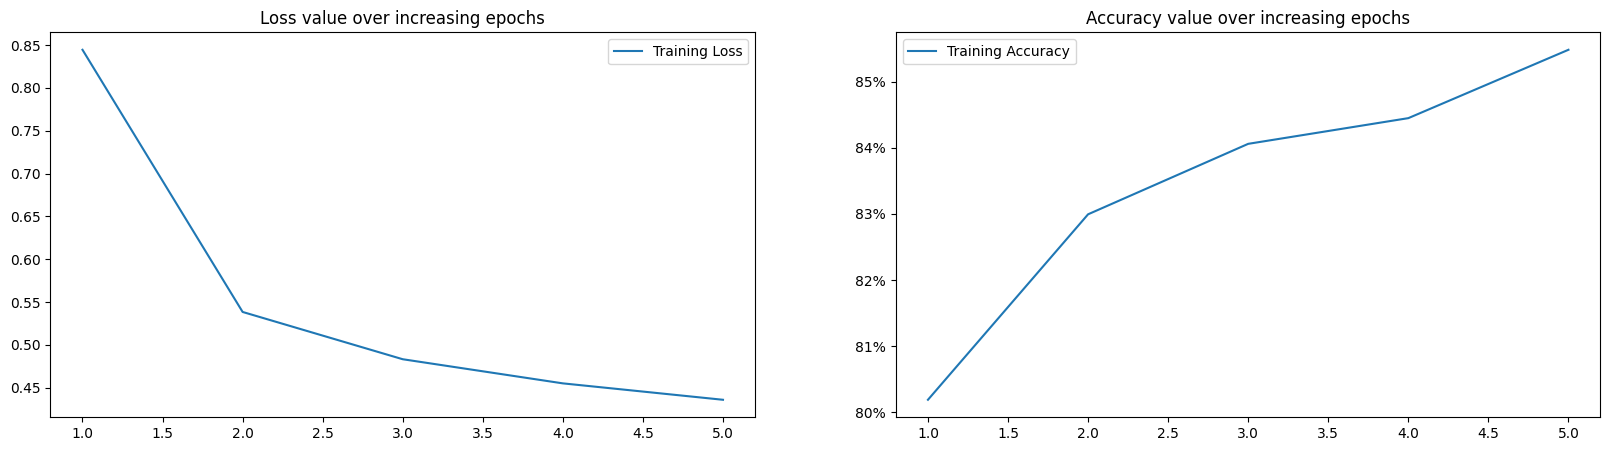

In [ ]:
trn_dl = get_data()
model, loss_fn, optimizer = get_model()
losses, accuracies = [], []
for epoch in range(5):
  print(epoch)
  epoch_losses = []
  # Calculate loss for all batches in the current epoch
  for ix, batch in enumerate(iter(trn_dl)):
    x, y = batch
    batch_loss = train_batch(x, y, model, optimizer, loss_fn)
    epoch_losses.append(batch_loss)
  # Calculate mean epoch loss and append once per epoch
  epoch_loss = np.array(epoch_losses).mean()
  losses.append(epoch_loss)

  epoch_accuracies = []
  # Calculate accuracy for all batches in the current epoch
  for ix, batch in enumerate(iter(trn_dl)):
    x, y = batch
    is_correct = accuracy(x, y, model)
    epoch_accuracies.extend(is_correct)
  # Calculate mean epoch accuracy and append once per epoch
  epoch_accuracy = np.mean(epoch_accuracies)
  accuracies.append(epoch_accuracy)

epochs = np.arange(5)+1
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.title('Loss value over increasing epochs')
plt.plot(epochs, losses, label='Training Loss')
plt.legend()
plt.subplot(122)
plt.title('Accuracy value over increasing epochs')
plt.plot(epochs, accuracies, label='Training Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in
plt.gca().get_yticks()])
plt.legend()
plt.show()

3. Chia tỉ lệ tập dữ liệu để cải thiện độ chính xác của mô hình

1. Tìm nạp tập dữ liệu cũng như các hình ảnh và gán nhãn vào biến tr_targets như chúng ta đã
làm trong phần trước:

In [ ]:
from torchvision import datasets
import torch

data_folder = '~/data/FMNIST'
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)
tr_images = fmnist.data
tr_targets = fmnist.targets

2. Sửa đổi FMNISTDataset để tìm nạp dữ liệu sao cho hình ảnh đầu vào được chia cho 255
(cường độ/giá trị tối đa của pixel)

In [ ]:
class FMNISTDataset(Dataset):
  def __init__(self, x, y):
    x = x.float()/255
    x = x.view(-1,28*28)
    self.x, self.y = x, y
  def __getitem__(self, ix):
    x, y = self.x[ix], self.y[ix]
    return x.to(device), y.to(device)
  def __len__(self):
    return len(self.x)

3. Huấn luyện một mô hình, giống như chúng ta đã làm ở các bước 4, 5, 6 và 7 của phần trước:


In [ ]:
def get_data():
  train = FMNISTDataset(tr_images, tr_targets)
  trn_dl = DataLoader(train, batch_size=32, shuffle=True)
  return trn_dl

from torch.optim import SGD
def get_model():
  model = nn.Sequential(
    nn.Linear(28 * 28, 1000),
    nn.ReLU(),
    nn.Linear(1000, 10)
  ).to(device)
  loss_fn = nn.CrossEntropyLoss()
  optimizer = SGD(model.parameters(), lr=1e-2)
  return model, loss_fn, optimizer

def train_batch(x, y, model, opt, loss_fn):
    model.train()
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    opt.step()
    opt.zero_grad()
    return batch_loss.item()

def accuracy(x, y, model):
  model.eval()
  with torch.no_grad():
    prediction = model(x)
  max_values, argmaxes = prediction.max(-1)
  is_correct = argmaxes == y
  return is_correct.cpu().numpy().tolist()

trn_dl = get_data()
model, loss_fn, optimizer = get_model()
losses, accuracies = [], []

for epoch in range(5):
  print(f"Epoch {epoch}")
  epoch_losses, epoch_accuracies = [], []
  for ix, batch in enumerate(iter(trn_dl)):
    x, y = batch
    batch_loss = train_batch(x, y, model, optimizer, loss_fn)
    epoch_losses.append(batch_loss)

  epoch_loss = np.array(epoch_losses).mean()

  for ix, batch in enumerate(iter(trn_dl)):
    x, y = batch
    is_correct = accuracy(x, y, model)
    epoch_accuracies.extend(is_correct)

  epoch_accuracy = np.mean(epoch_accuracies)

  # These must be indented to be inside the epoch loop
  losses.append(epoch_loss)
  accuracies.append(epoch_accuracy)

Epoch 0
Epoch 1
Epoch 2
Epoch 3
Epoch 4


4. Vẽ biểu đồ độ chính xác và sai số:


/tmp/ipykernel_263/1974019101.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


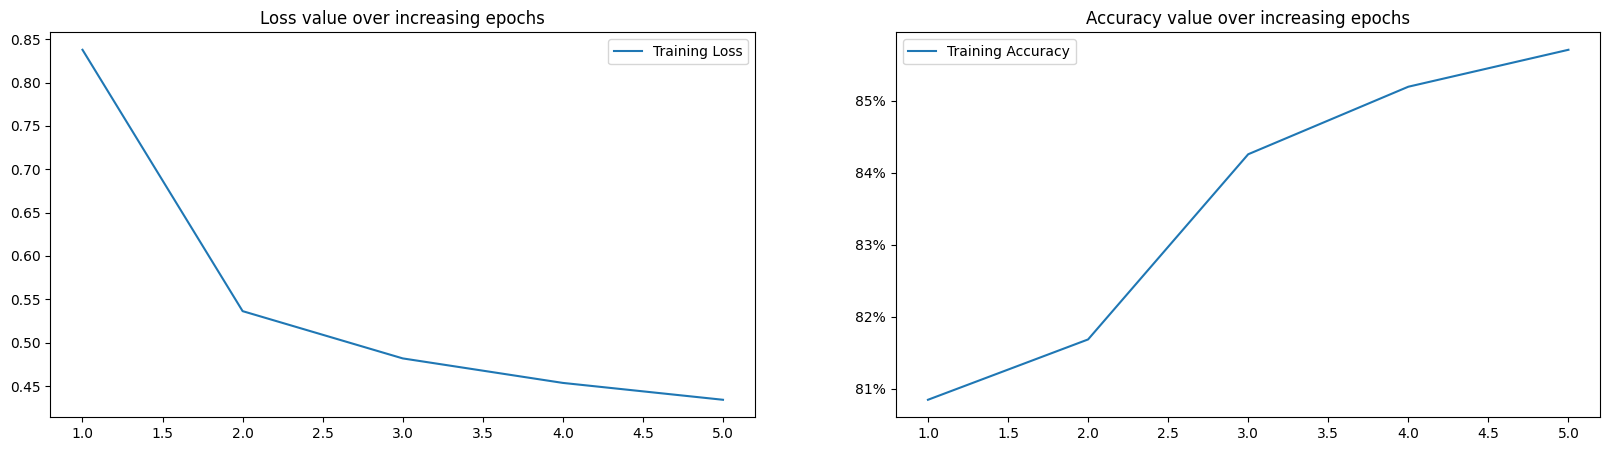

In [ ]:
epochs = np.arange(5)+1
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(20,5))

plt.subplot(121)
plt.title('Loss value over increasing epochs')
plt.plot(epochs, losses, label='Training Loss')
plt.legend()

plt.subplot(122)
plt.title('Accuracy value over increasing epochs')
plt.plot(epochs, accuracies, label='Training Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])
plt.legend()

plt.show()

4. Hiểu được tác động của việc thay đổi kích thước bó


1. Tải xuống và import các hình ảnh huấn luyện và gán nhãn vào biến tr_targets:


In [ ]:
from torchvision import datasets
import torch
data_folder = '~/data/FMNIST' # This can be any directory you want to
# download FMNIST to
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)
tr_images = fmnist.data
tr_targets = fmnist.targets


2. Theo cách tương tự với hình ảnh huấn luyện, chúng ta phải tải xuống và nhập tập dữ liệu xác
thực bằng cách chỉ định train = False trong khi gọi phương thức FashionMNIST trong bộ dữ liệu
của chúng ta:


In [ ]:
val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False)
val_images = val_fmnist.data
val_targets = val_fmnist.targets



3. Import các gói có liên quan và xác định thiết bị:

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from torch.utils.data import Dataset, DataLoader

import torch
import torch.nn as nn
device = 'cuda' if torch.cuda.is_available() else 'cpu'

4. Xác định lớp tập dữ liệu (FashionMNIST), các hàm sẽ được sử dụng để huấn luyện trên một
bó dữ liệu (train_batch), tính toán độ chính xác (accuracy), sau đó xác định kiến trúc mô hình,
hàm sai số và trình tối ưu hóa (get_model). Lưu ý rằng hàm lấy dữ liệu sẽ là hàm duy nhất có sai
lệch so với những gì chúng ta đã thấy trong các phần trước (vì chúng ta hiện đang nghiên cứu
các tập dữ liệu huấn luyện và xác thực), vì vậy chúng ta sẽ xây dựng nó trong bước tiếp theo:

In [ ]:
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float()/255
        x = x.view(-1,28*28)
        self.x, self.y = x, y

    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        return x.to(device), y.to(device)

    def __len__(self):
        return len(self.x)

from torch.optim import SGD, Adam

def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-2)
    return model, loss_fn, optimizer

def train_batch(x, y, model, opt, loss_fn):
    model.train()
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    opt.step()         # Sửa từ optimizer.step() thành opt.step()
    opt.zero_grad()    # Sửa từ optimizer.zero_grad() thành opt.zero_grad()
    return batch_loss.item()

def accuracy(x, y, model):
    model.eval()
    with torch.no_grad():
        prediction = model(x)
        max_values, argmaxes = prediction.max(-1)
        is_correct = argmaxes == y
        return is_correct.cpu().numpy().tolist()

5. Xác định hàm sẽ lấy dữ liệu; hàm get_data. Hàm này sẽ trả về dữ liệu huấn luyện với kích
thước bó là 32 và tập dữ liệu xác thực có kích thước bó bằng độ dài của dữ liệu xác thực (chúng
ta sẽ không sử dụng dữ liệu xác thực để huấn luyện mô hình; chúng ta sẽ chỉ sử dụng dữ liệu đó
để hiểu độ chính xác của mô hình khi không nhìn thấy được dữ liệu):


In [ ]:
def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)
    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False)
    return trn_dl, val_dl

6. Xác định hàm tính toán việc mất dữ liệu xác thực; cái đó là, val_loss. Lưu ý rằng chúng ta
đang tính toán giá trị này một cách riêng biệt vì mất dữ liệu huấn luyện đang được tính toán
trong khi huấn luyện mô hình:


In [ ]:
@torch.no_grad()
def val_loss(x, y, model):
    prediction = model(x)
    val_loss = loss_fn(prediction, y)
    return val_loss.item()

7. Tìm nạp DataLoaders huấn luyện và xác thực. Ngoài ra, hãy khởi tạo mô hình, hàm sai số và
trình tối ưu hóa:
trn_dl, val_dl

In [ ]:
trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

8. Huấn luyện mô hình như sau:
train_losses, train_accurac

In [ ]:
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(5):
    print(epoch)
    train_epoch_losses, train_epoch_accuracies = [], []

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)
    train_epoch_loss = np.array(train_epoch_losses).mean()

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)
    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model)
        val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)

0
1
2
3
4


9. Trực quan hóa

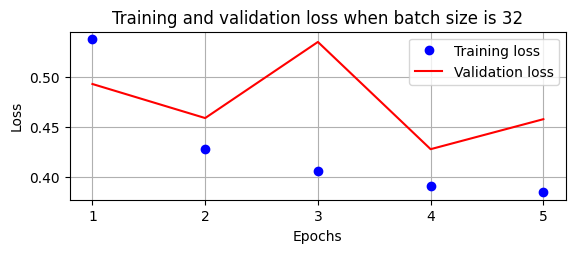

/tmp/ipykernel_263/3551033221.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


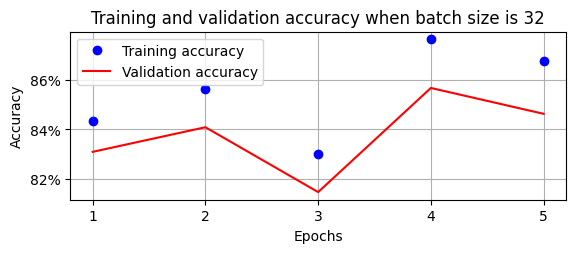

In [ ]:
epochs = np.arange(5)+1
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline

plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation loss when batch size is 32')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid('off')
plt.show()

plt.subplot(212)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation accuracy when batch size is 32')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])
plt.legend()
plt.grid('off')
plt.show()

0
1
2
3
4
5
6
7
8
9


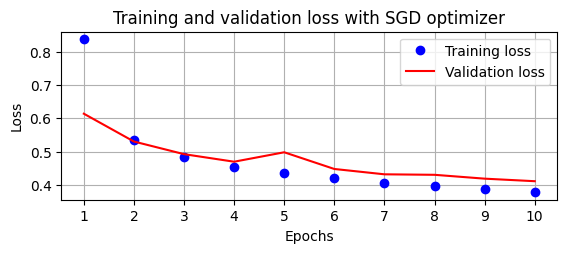

/tmp/ipykernel_263/1655694623.py:171: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(


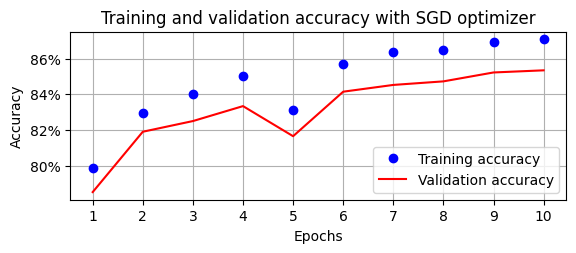

In [ ]:
from torchvision import datasets
import torch

data_folder = '~/data/FMNIST'  # This can be any directory you want to download FMNIST to

fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)
tr_images = fmnist.data
tr_targets = fmnist.targets

val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False)
val_images = val_fmnist.data
val_targets = val_fmnist.targets

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn

device = 'cuda' if torch.cuda.is_available() else 'cpu'


# SGD optimizer
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float() / 255
        x = x.view(-1, 28 * 28)
        self.x, self.y = x, y

    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        return x.to(device), y.to(device)

    def __len__(self):
        return len(self.x)


from torch.optim import SGD, Adam


def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = SGD(model.parameters(), lr=1e-2)

    return model, loss_fn, optimizer


def train_batch(x, y, model, opt, loss_fn):
    model.train()
    prediction = model(x)

    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()

    optimizer.step()
    optimizer.zero_grad()

    return batch_loss.item()


def accuracy(x, y, model):
    model.eval()

    # this is the same as @torch.no_grad
    # at the top of function, only difference
    # being, grad is not computed in the with scope
    with torch.no_grad():
        prediction = model(x)

    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y

    return is_correct.cpu().numpy().tolist()


def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)

    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False)

    return trn_dl, val_dl


@torch.no_grad()
def val_loss(x, y, model):
    prediction = model(x)
    val_loss = loss_fn(prediction, y)
    return val_loss.item()


trn_dl, val_dl = get_data()

model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(10):
    print(epoch)

    train_epoch_losses, train_epoch_accuracies = [], []

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.array(train_epoch_losses).mean()

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)

    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model)

    val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)

    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)


epochs = np.arange(10) + 1

import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline

plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title('Training and validation loss with SGD optimizer')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.grid('off')
plt.show()


plt.subplot(212)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title('Training and validation accuracy with SGD optimizer')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.gca().set_yticklabels(
    ['{:.0f}%'.format(x * 100) for x in plt.gca().get_yticks()]
)

plt.legend()
plt.grid('off')

0
1
2
3
4


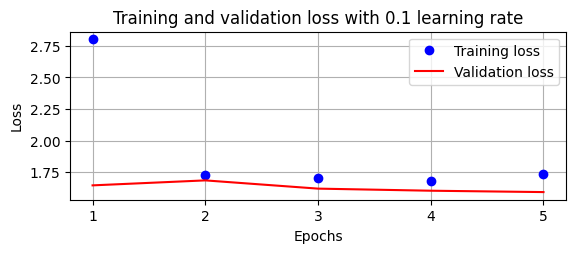

/tmp/ipykernel_263/3846803961.py:173: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(


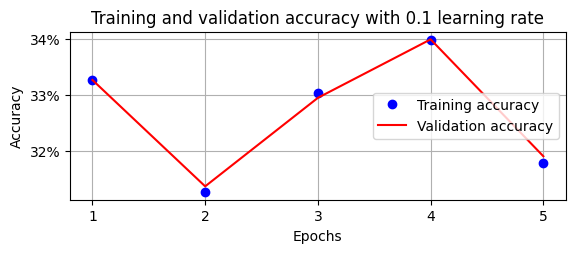

In [ ]:
from torchvision import datasets
import torch

data_folder = '~/data/FMNIST'  # This can be any directory you want to download FMNIST to

fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)
tr_images = fmnist.data
tr_targets = fmnist.targets

val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False)
val_images = val_fmnist.data
val_targets = val_fmnist.targets

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn

device = 'cuda' if torch.cuda.is_available() else 'cpu'


# High Learning Rate
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float() / 255
        x = x.view(-1, 28 * 28)
        self.x, self.y = x, y

    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        return x.to(device), y.to(device)

    def __len__(self):
        return len(self.x)


from torch.optim import SGD, Adam


def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-1)

    return model, loss_fn, optimizer


def train_batch(x, y, model, opt, loss_fn):
    model.train()

    prediction = model(x)
    batch_loss = loss_fn(prediction, y)

    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    return batch_loss.item()


def accuracy(x, y, model):
    model.eval()

    # this is the same as @torch.no_grad
    # at the top of function, only difference
    # being, grad is not computed in the with scope
    with torch.no_grad():
        prediction = model(x)

    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y

    return is_correct.cpu().numpy().tolist()


def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)

    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False)

    return trn_dl, val_dl


@torch.no_grad()
def val_loss(x, y, model):
    prediction = model(x)
    val_loss = loss_fn(prediction, y)
    return val_loss.item()


trn_dl, val_dl = get_data()

model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(5):
    print(epoch)

    train_epoch_losses, train_epoch_accuracies = [], []

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.array(train_epoch_losses).mean()

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)

    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model)

    val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)

    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)


epochs = np.arange(5) + 1

import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline


plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title('Training and validation loss with 0.1 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.grid('off')
plt.show()


plt.subplot(212)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title('Training and validation accuracy with 0.1 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.gca().set_yticklabels(
    ['{:.0f}%'.format(x * 100) for x in plt.gca().get_yticks()]
)

plt.legend()
plt.grid('off')
plt.show()

Tốc độ học trung bình


0
1
2
3
4


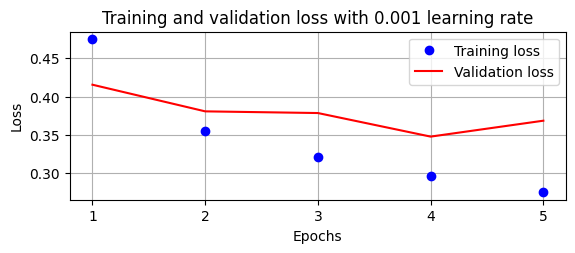

/tmp/ipykernel_263/1208455462.py:88: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(


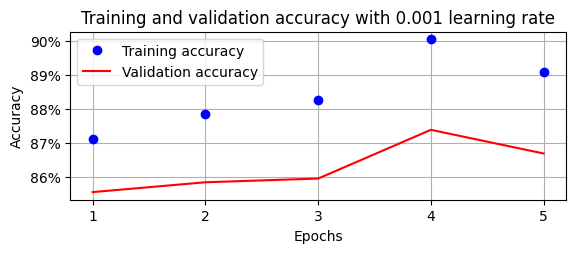

In [ ]:
# Medium Learning Rate (0.001)

def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-3)

    return model, loss_fn, optimizer


trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(5):
    print(epoch)

    train_epoch_losses, train_epoch_accuracies = [], []

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.array(train_epoch_losses).mean()

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)

    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model)

    val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)

    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)


epochs = np.arange(5) + 1

import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline


plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title('Training and validation loss with 0.001 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.grid('off')
plt.show()


plt.subplot(212)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title('Training and validation accuracy with 0.001 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.gca().set_yticklabels(
    ['{:.0f}%'.format(x * 100) for x in plt.gca().get_yticks()]
)

plt.legend()
plt.grid('off')
plt.show()

Tốc độ học thấp


0
1
2
3
4


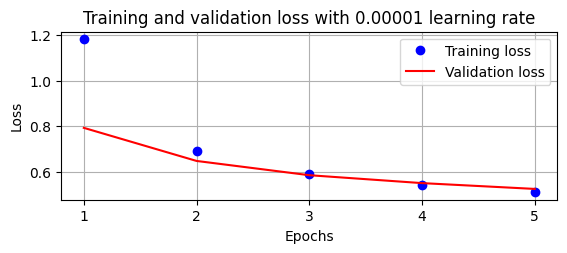

/tmp/ipykernel_263/509788513.py:88: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(


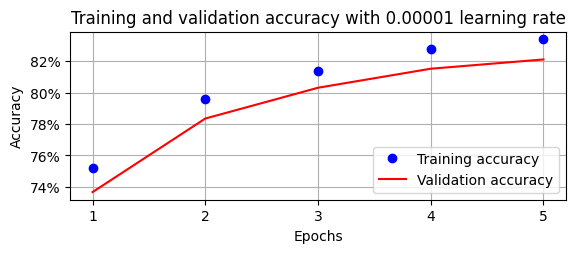

In [ ]:
# Low Learning Rate (0.00001)

def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-5)

    return model, loss_fn, optimizer


trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(5):
    print(epoch)

    train_epoch_losses, train_epoch_accuracies = [], []

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.array(train_epoch_losses).mean()

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)

    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model)

    val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)

    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)


epochs = np.arange(5) + 1

import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline


plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title('Training and validation loss with 0.00001 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.grid('off')
plt.show()


plt.subplot(212)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title('Training and validation accuracy with 0.00001 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.gca().set_yticklabels(
    ['{:.0f}%'.format(x * 100) for x in plt.gca().get_yticks()]
)

plt.legend()
plt.grid('off')
plt.show()

Tác động của việc thay đổi tốc độ học trên tập dữ liệu không được chia tỷ lệ


0
1
2
3
4


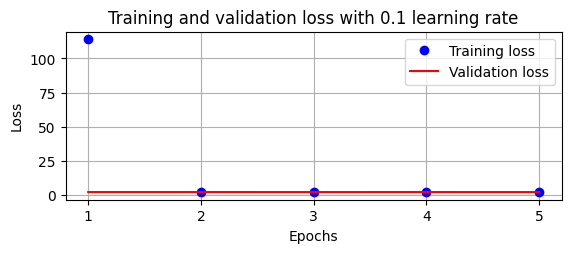

/tmp/ipykernel_263/2436873262.py:170: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(


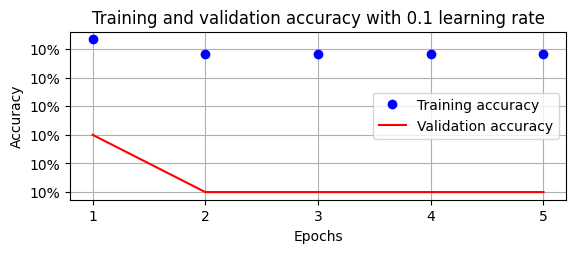

In [ ]:
from torchvision import datasets
import torch

data_folder = '~/data/FMNIST'

fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)
tr_images = fmnist.data
tr_targets = fmnist.targets

val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False)
val_images = val_fmnist.data
val_targets = val_fmnist.targets

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

device = 'cuda' if torch.cuda.is_available() else 'cpu'


# High Learning Rate (không scale dữ liệu)
class FMNISTDataset(Dataset):

    def __init__(self, x, y):
        x = x.float()          # KHÔNG chia cho 255
        x = x.view(-1, 28*28)
        self.x, self.y = x, y

    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        return x.to(device), y.to(device)

    def __len__(self):
        return len(self.x)


from torch.optim import Adam


def get_model():
    model = nn.Sequential(
        nn.Linear(28*28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-1)

    return model, loss_fn, optimizer


def train_batch(x, y, model, optimizer, loss_fn):
    model.train()

    prediction = model(x)
    batch_loss = loss_fn(prediction, y)

    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    return batch_loss.item()


def accuracy(x, y, model):

    model.eval()

    with torch.no_grad():
        prediction = model(x)
        max_values, argmaxes = prediction.max(-1)

        is_correct = argmaxes == y

    return is_correct.cpu().numpy().tolist()


def get_data():

    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)

    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False)

    return trn_dl, val_dl


@torch.no_grad()
def val_loss(x, y, model):
    prediction = model(x)
    loss = loss_fn(prediction, y)
    return loss.item()


trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []


for epoch in range(5):

    print(epoch)

    train_epoch_losses, train_epoch_accuracies = [], []

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.array(train_epoch_losses).mean()

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)

    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model)

    val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)

    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)


epochs = np.arange(5) + 1

import matplotlib.ticker as mticker


plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title('Training and validation loss with 0.1 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.grid('off')
plt.show()


plt.subplot(212)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title('Training and validation accuracy with 0.1 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.gca().set_yticklabels(
    ['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()]
)

plt.legend()
plt.grid('off')
plt.show()

Tốc độ học trung bình:


0
1
2
3
4


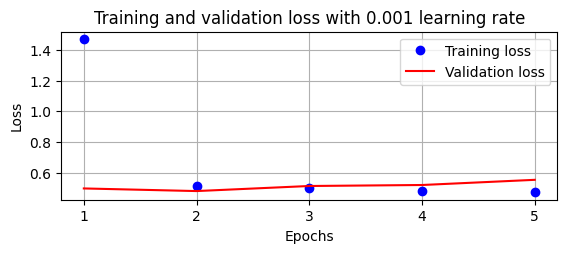

/tmp/ipykernel_263/1062093365.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(


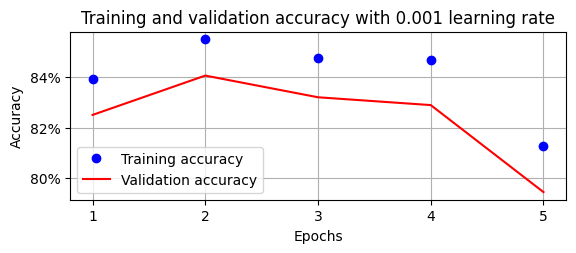

In [ ]:
# Medium Learning Rate (0.001)

def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-3)

    return model, loss_fn, optimizer


trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(5):
    print(epoch)

    train_epoch_losses, train_epoch_accuracies = [], []

    # Training
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.array(train_epoch_losses).mean()

    # Training accuracy
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)

    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    # Validation
    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model)

    val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)

    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)


epochs = np.arange(5) + 1

import matplotlib.ticker as mticker
import matplotlib.pyplot as plt

%matplotlib inline


# Loss plot
plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title('Training and validation loss with 0.001 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.grid('off')
plt.show()


# Accuracy plot
plt.subplot(212)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title('Training and validation accuracy with 0.001 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.gca().set_yticklabels(
    ['{:.0f}%'.format(x * 100) for x in plt.gca().get_yticks()]
)

plt.legend()
plt.grid('off')
plt.show()

Tốc độ học thấp:

0
1
2
3
4


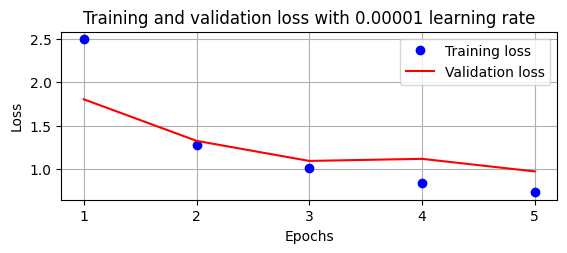

/tmp/ipykernel_263/2945083580.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


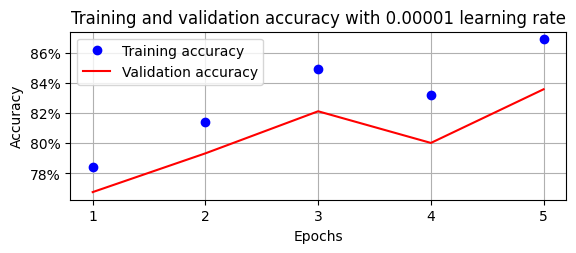

In [ ]:
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-5)

    return model, loss_fn, optimizer


trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(5):
    print(epoch)

    train_epoch_losses, train_epoch_accuracies = [], []

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.array(train_epoch_losses).mean()

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)

    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model)

    val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)

    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)


epochs = np.arange(5) + 1

import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline


plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title('Training and validation loss with 0.00001 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.grid('off')
plt.show()


plt.subplot(212)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title('Training and validation accuracy with 0.00001 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])

plt.legend()
plt.grid('off')
plt.show()

Cat and Dog


Found 24769 files belonging to 2 classes.
Using 19816 files for training.
Found 24769 files belonging to 2 classes.
Using 4953 files for validation.
Epoch 1/5
620/620 ━━━━━━━━━━━━━━━━━━━━ 51s 66ms/step - accuracy: 0.9685 - loss: 0.0877 - val_accuracy: 0.9851 - val_loss: 0.0500
Epoch 2/5
620/620 ━━━━━━━━━━━━━━━━━━━━ 66s 48ms/step - accuracy: 0.9830 - loss: 0.0485 - val_accuracy: 0.9851 - val_loss: 0.0450
Epoch 3/5
620/620 ━━━━━━━━━━━━━━━━━━━━ 32s 52ms/step - accuracy: 0.9842 - loss: 0.0426 - val_accuracy: 0.9859 - val_loss: 0.0445
Epoch 4/5
620/620 ━━━━━━━━━━━━━━━━━━━━ 33s 54ms/step - accuracy: 0.9856 - loss: 0.0399 - val_accuracy: 0.9859 - val_loss: 0.0442
Epoch 5/5
620/620 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.9851 - loss: 0.0389 - val_accuracy: 0.9853 - val_loss: 0.0455

Độ chính xác cuối cùng (Validation Accuracy): 98.53%
Độ sai số cuối cùng (Validation Loss): 0.0455

4. Đang vẽ biểu đồ kết quả...


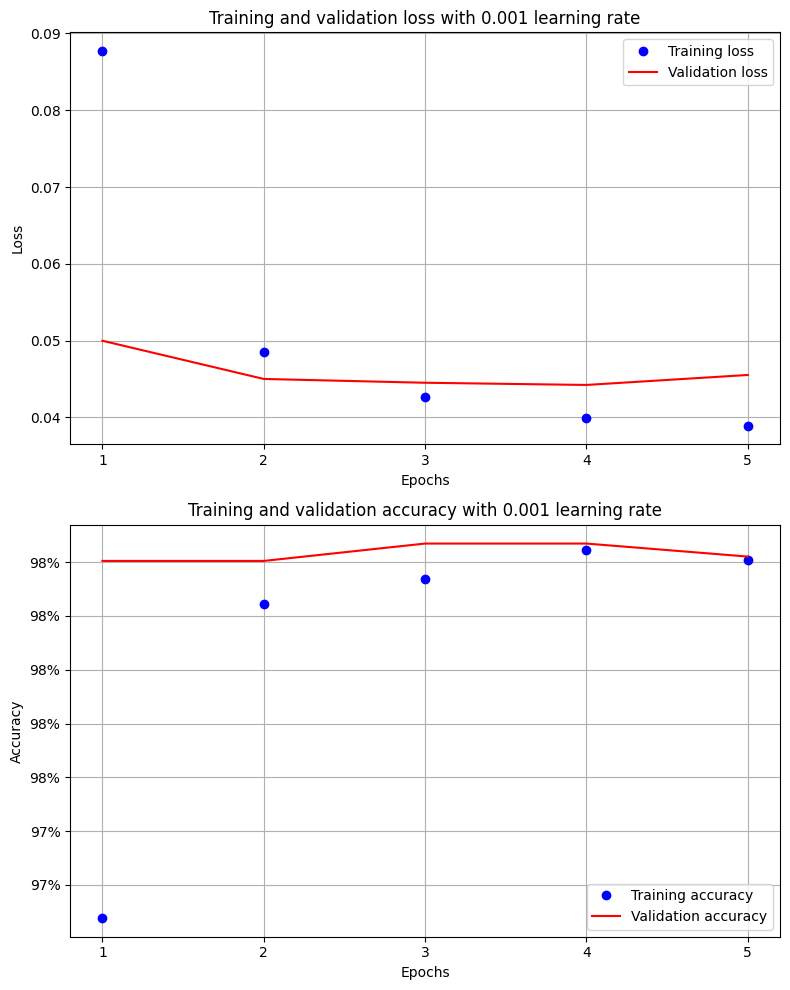

In [14]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

_URL = 'https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip'
path_to_zip = tf.keras.utils.get_file('cats_and_dogs.zip', origin=_URL, extract=True)

base_dir = os.path.dirname(path_to_zip)
PATH = os.path.join(base_dir, 'PetImages')

if not os.path.exists(PATH):
    for root, dirs, files in os.walk(base_dir):
        if 'PetImages' in dirs:
            PATH = os.path.join(root, 'PetImages')
            break

for folder in ['Cat', 'Dog']:
    folder_path = os.path.join(PATH, folder)
    if os.path.exists(folder_path):
        for file in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file)
            try:
                is_valid = tf.io.is_jpeg(tf.io.read_file(file_path))
                if not is_valid or os.path.getsize(file_path) == 0:
                    os.remove(file_path)
            except:
                os.remove(file_path)

BATCH_SIZE = 32
IMG_SIZE = (160, 160)

train_dataset = image_dataset_from_directory(
    PATH, validation_split=0.2, subset='training', seed=123,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE)

validation_dataset = image_dataset_from_directory(
    PATH, validation_split=0.2, subset='validation', seed=123,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE)

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input
base_model = MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet')
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model = models.Model(inputs, outputs)

LEARNING_RATE = 0.001

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy'])

EPOCHS = 5
history = model.fit(train_dataset, epochs=EPOCHS, validation_data=validation_dataset)

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

final_val_accuracy = val_acc[-1]
final_val_loss = val_loss[-1]

print(f"\nĐộ chính xác cuối cùng (Validation Accuracy): {final_val_accuracy * 100:.2f}%")
print(f"Độ sai số cuối cùng (Validation Loss): {final_val_loss:.4f}")
print("="*50)
print("\n4. Đang vẽ biểu đồ kết quả...")

plt.figure(figsize=(8, 10))

plt.subplot(2, 1, 1)
plt.plot(epochs_range, loss, 'bo', label='Training loss')
plt.plot(epochs_range, val_loss, 'r', label='Validation loss')
plt.title(f'Training and validation loss with {LEARNING_RATE} learning rate')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(epochs_range)
plt.legend(loc='upper right')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(epochs_range, acc, 'bo', label='Training accuracy')
plt.plot(epochs_range, val_acc, 'r', label='Validation accuracy')
plt.title(f'Training and validation accuracy with {LEARNING_RATE} learning rate')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xticks(epochs_range)

ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))

plt.legend(loc='lower right')
plt.grid(True)

plt.tight_layout()
plt.show()